In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

In [5]:
df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",encoding="latin1")

In [6]:
df = df.sample(n=100000,random_state=42).reset_index(drop='True')

In [7]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,2200003313,Tue Jun 16 18:18:13 PDT 2009,NO_QUERY,DEWGetMeTho77,@Nkluvr4eva My poor little dumpling In Holmde...
1,0,1467998601,Mon Apr 06 23:11:18 PDT 2009,NO_QUERY,Young_J,I'm off too bed. I gotta wake up hella early t...
2,0,2300049112,Tue Jun 23 13:40:12 PDT 2009,NO_QUERY,dougnawoschik,I havent been able to listen to it yet My spe...
3,0,1993474319,Mon Jun 01 10:26:09 PDT 2009,NO_QUERY,thireven,now remembers why solving a relatively big equ...
4,0,2256551006,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,taracollins086,"Ate too much, feel sick"


In [8]:
cols = ['target','id','date','flag','user','text']

df = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",names=cols,encoding='latin1')

In [11]:
df = df.sample(n=100000,random_state=42).reset_index(drop='True')

In [12]:
df.shape

(100000, 6)

In [13]:
df.head()

,target,id,date,flag,user,text
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo..."
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem


In [14]:
print(df['target'].value_counts())

target
4    50057
0    49943
Name: count, dtype: int64


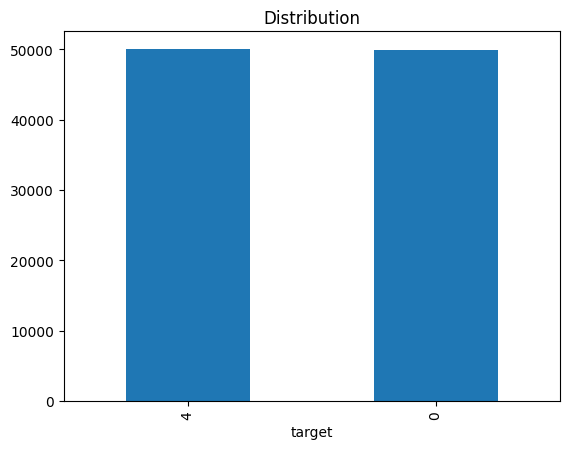

In [20]:
df['target'].value_counts().plot(kind='bar',title="Distribution")
plt.show()

In [23]:
df.replace({'target':{4:1}},inplace=True)
df['target'].value_counts()

,count
target,
1,50057
0,49943


In [24]:
df.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   target  100000 non-null  int64 
 1   id      100000 non-null  int64 
 2   date    100000 non-null  object
 3   flag    100000 non-null  object
 4   user    100000 non-null  object
 5   text    100000 non-null  object
dtypes: int64(2), object(4)
memory usage: 4.6+ MB
None


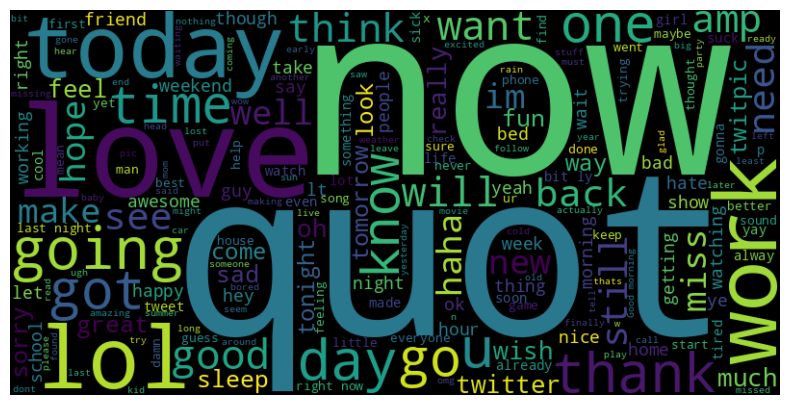

In [38]:
text = " ".join(tweet for tweet in df['text'])
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

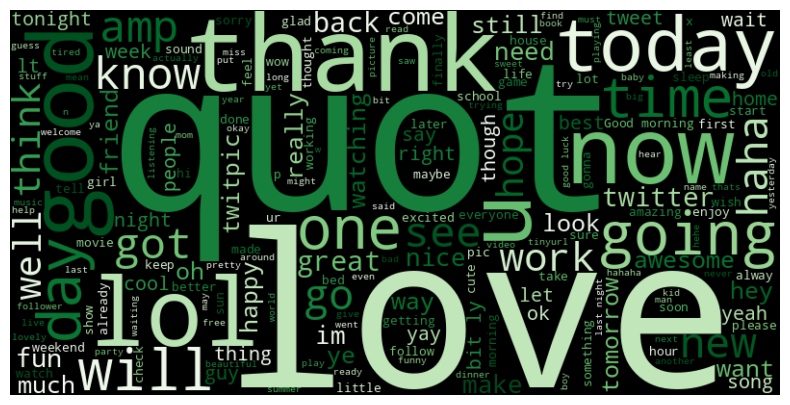

In [35]:
positive_text = " ".join(df[df['target']==1]['text'].astype(str))
positive_wc = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

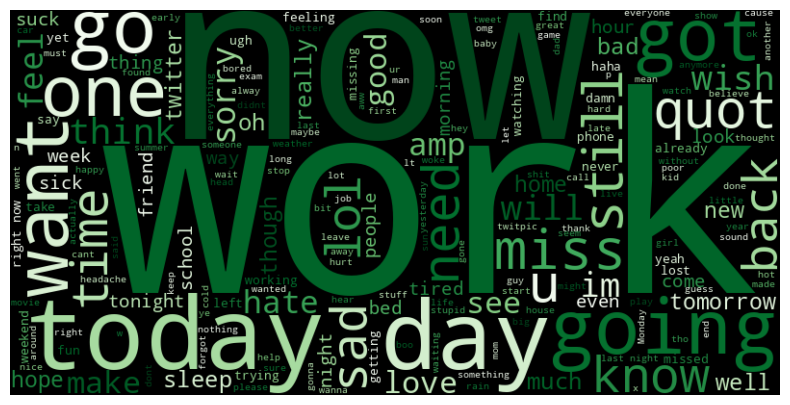

In [36]:
negative_text = " ".join(df[df['target']==0]['text'].astype(str))
negative_wc = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [48]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.lower()
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(clean_tweet)
df['cleaned_text'][100]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'oh ive got case designed someone idiot stole prove want play hardballim game'

In [49]:
df.head()

,target,id,date,flag,user,text,cleaned_text
0,0,2200003196,Tue Jun 16 18:18:12 PDT 2009,NO_QUERY,LaLaLindsey0609,@chrishasboobs AHHH I HOPE YOUR OK!!!,ahhh hope ok
1,0,1467998485,Mon Apr 06 23:11:14 PDT 2009,NO_QUERY,sexygrneyes,"@misstoriblack cool , i have no tweet apps fo...",cool tweet apps razr
2,0,2300048954,Tue Jun 23 13:40:11 PDT 2009,NO_QUERY,sammydearr,@TiannaChaos i know just family drama. its la...,know family drama lamehey next time u hang kim...
3,0,1993474027,Mon Jun 01 10:26:07 PDT 2009,NO_QUERY,Lamb_Leanne,School email won't open and I have geography ...,school email wont open geography stuff revise ...
4,0,2256550904,Sat Jun 20 12:56:51 PDT 2009,NO_QUERY,yogicerdito,upper airways problem,upper airway problem


In [54]:
X=df['cleaned_text'].values
y=df['target'].values

In [55]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000,)
(20000,)
(80000,)
(20000,)


In [58]:
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf= tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [60]:
print(X_train_tfidf.shape)

(80000, 10000)


In [61]:
lr_model = LogisticRegression(max_iter=500)
lr_model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=500)

In [62]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [63]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76      9995
           1       0.75      0.78      0.77     10005

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



In [64]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.75      0.75      0.75      9995
           1       0.75      0.74      0.75     10005

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000



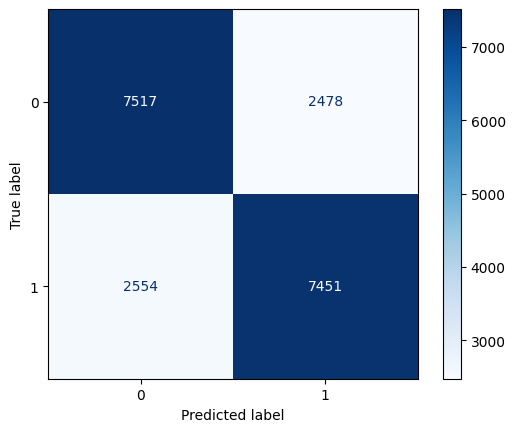

In [66]:

from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
plt.show()


In [71]:
from sklearn.model_selection import GridSearchCV

params = {'C':[0.1,1,10], 'max_iter':[200,400]}
grid = GridSearchCV(LogisticRegression(), params, cv=3)
grid.fit(X_train_tfidf, y_train)
print(grid.best_score_)


0.7601874882061611
